In [ ]:
# Базовые библиотеки
import os
import sys
import math
import time
import random
from typing import Tuple, Dict, List
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
from torchvision import datasets
import copy

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset

# Датасеты / трансформации
import torchvision
from torchvision import transforms
from dataclasses import dataclass
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.models import swin_t, Swin_T_Weights
from torchvision.datasets.utils import download_and_extract_archive
from torchvision.datasets import VOCDetection
import json
from pathlib import Path

from PIL import Image
import torch.utils.data
import xml.etree.ElementTree as ET

In [ ]:
# фиксация seed
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [ ]:
# определение устройства
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


Набор данных представляет собой регненовские изображения грудной клетки,включающий в себя 4 класса: «Ковид», «Норма», «Непрозрачность легких» (НЛ) и «Вирусная пневмония» (ВП).

Распаковка архива с набором данных и разделение его на 3 выборки: train, test, valid

In [ ]:
from google.colab import drive

drive.mount('/content/drive')
with zipfile.ZipFile('/content/drive/MyDrive/archive (8).zip', 'r') as zip_ref:
    zip_ref.extractall('/content/папка_для_распаковки')


Mounted at /content/drive


In [ ]:
import os, shutil, random
from pathlib import Path

src = Path("/content/папка_для_распаковки")      # здесь 4 папки классов
dst = Path("/content/папка_для разделения")      # сюда лягут train/val/test
ratios = (0.7, 0.15, 0.15)               # train, val, test
random.seed(42)

for class_dir in sorted(src.iterdir()):
    if not class_dir.is_dir():
        continue
    files = [f for f in class_dir.iterdir() if f.is_file()]
    random.shuffle(files)
    n_train = int(len(files) * ratios[0])
    n_val   = int(len(files) * ratios[1])

    train_files = files[:n_train]
    val_files   = files[n_train:n_train + n_val]
    test_files  = files[n_train + n_val:]

    for split, file_list in zip(["train", "val", "test"],
                                 [train_files, val_files, test_files]):
        out_dir = dst / split / class_dir.name
        out_dir.mkdir(parents=True, exist_ok=True)
        for f in file_list:
            shutil.copy2(f, out_dir / f.name)   # или shutil.move() при нужде

print("Готово")

Готово


In [ ]:
from pathlib import Path

dst = Path("/content/папка_для разделения")   # та же папка, куда складывал результат

for split_dir in sorted(dst.iterdir()):                # train, val, test
    if split_dir.is_dir():
        print(f"\n {split_dir.name}")
        for class_dir in sorted(split_dir.iterdir()):  # подпапки классов
            if class_dir.is_dir():
                n = len(list(class_dir.iterdir()))     # количество файлов
                print(f"  {class_dir.name}: {n}")


 test
  COVID: 1313
  Lung opacity: 1152
  Normal: 1233
  Viral Pneumonia: 806

 train
  COVID: 6121
  Lung opacity: 5371
  Normal: 5749
  Viral Pneumonia: 3755

 val
  COVID: 1311
  Lung opacity: 1151
  Normal: 1232
  Viral Pneumonia: 804


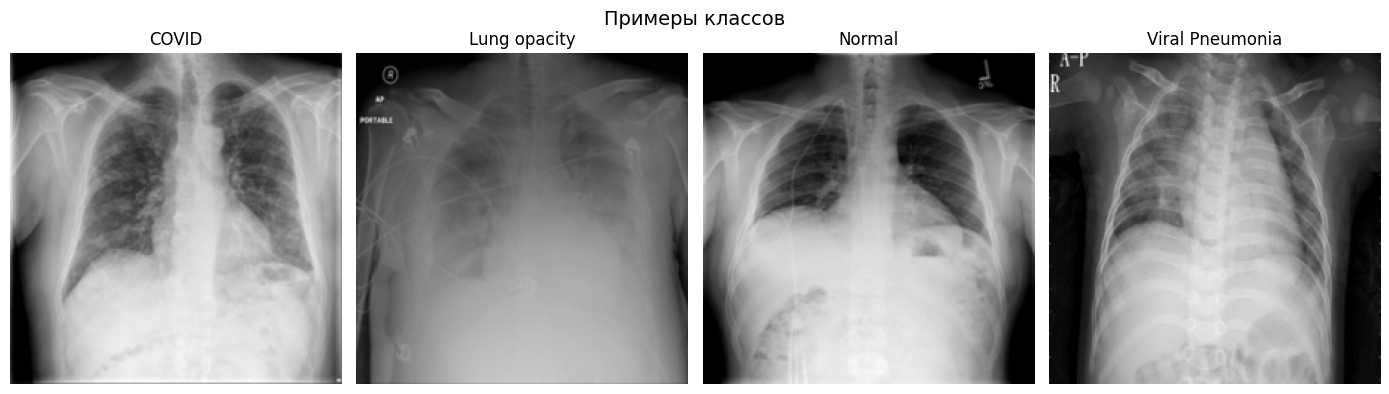

In [ ]:
base_dir = '/content/папка_для_распаковки'
class_names = sorted(os.listdir(base_dir))

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for i, cls in enumerate(class_names):
    img_name = random.choice(os.listdir(f'{base_dir}/{cls}'))
    img = Image.open(f'{base_dir}/{cls}/{img_name}')
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(cls, fontsize=12)
    axes[i].axis('off')
plt.suptitle('Примеры классов', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
def make_loaders_tl(ds_train, ds_val, ds_test, batch_size=64):
    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(ds_test, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader

Снчала продемонстрируем бэзлайн модели ввиде простых CNN с и без аугментаций, для понимания, от какого результата мне отталкивается

In [ ]:
def compute_mean_std(dataset):
    loader = DataLoader(dataset, batch_size=256, shuffle=False, num_workers=2)
    mean = torch.zeros(3)
    std = torch.zeros(3)
    total = 0

    for x, _ in loader:
        # x: [B, C, H, W]
        mean += x.mean(dim=[0, 2, 3]) * x.size(0)  # среднее по H,W для каждого канала
        std += x.std(dim=[0, 2, 3]) * x.size(0)
        total += x.size(0)

    mean /= total
    std /= total
    return mean.tolist(), std.tolist()

# Временный датасет без нормализации
ds_for_stats = datasets.ImageFolder(
    root="/content/папка_для разделения/train",
    transform=transforms.ToTensor()  # только [0,1], без Normalize
)

MEAN_CUSTOM, STD_CUSTOM = compute_mean_std(ds_for_stats)
print(f"MEAN: {[round(m, 4) for m in MEAN_CUSTOM]}")
print(f"STD:  {[round(s, 4) for s in STD_CUSTOM]}")

MEAN: [0.5353, 0.5353, 0.5353]
STD:  [0.2547, 0.2547, 0.2547]


In [ ]:
IMG_SIZE = 224

tf_train_no_aug = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN_CUSTOM, STD_CUSTOM),
])

train_aug = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.RandomCrop(IMG_SIZE, padding=16),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN_CUSTOM, STD_CUSTOM),
])

tf_test = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN_CUSTOM, STD_CUSTOM),
])

ds_train_aug_baseline = datasets.ImageFolder(root="/content/папка_для разделения/train", transform=train_aug)
ds_train_no_aug = datasets.ImageFolder(root="/content/папка_для разделения/train", transform=tf_train_no_aug)
ds_val_baseline = datasets.ImageFolder(root="/content/папка_для разделения/val", transform=tf_test)
ds_test_baseline = datasets.ImageFolder(root="/content/папка_для разделения/test", transform=tf_test)

In [ ]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = 5, verbose: bool = True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – обычно это признак проблем с LR/стабильностью. Останавливаем обучение.")
            break

    return history

def plot_history(hist: Dict[str, List[float]], title: str = "") -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

In [ ]:
def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 4):
        super().__init__()
        self.features = nn.Sequential(
            # Блок 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 224→112
            # Блок 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2), # 112→56
            # Блок 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),# 56→28
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # 28→1
            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
cnn = SimpleCNN(4).to(DEVICE)
print(cnn)
print("Trainable params:", count_params(cnn))

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=4, bias=True)
  )
)
Trainable params: 101764


простая CNN без аугментаций.

In [ ]:
train_loader_c1, val_loader_c1, test_loader_c1 = make_loaders_tl(
    ds_train_no_aug, ds_val_baseline, ds_test_baseline, batch_size=64
)

batch_c1 = next(iter(train_loader_c1))
x_c1, y_c1 = batch_c1
print("x:", x_c1.shape, x_c1.dtype)
print("y:", y_c1.shape, y_c1.dtype)

x: torch.Size([64, 3, 224, 224]) torch.float32
y: torch.Size([64]) torch.int64


Epoch 01/15 | train loss 1.2166, acc 0.443 | val loss 1.0317, acc 0.563 | 123.7s
Epoch 02/15 | train loss 1.0031, acc 0.567 | val loss 0.9328, acc 0.600 | 118.5s
Epoch 03/15 | train loss 0.9174, acc 0.605 | val loss 0.9006, acc 0.600 | 117.9s
Epoch 04/15 | train loss 0.8584, acc 0.636 | val loss 0.8201, acc 0.660 | 114.9s
Epoch 05/15 | train loss 0.8068, acc 0.662 | val loss 0.7501, acc 0.697 | 117.8s
Epoch 06/15 | train loss 0.7627, acc 0.683 | val loss 0.7093, acc 0.705 | 123.0s
Epoch 07/15 | train loss 0.7369, acc 0.693 | val loss 0.7061, acc 0.717 | 117.7s
Epoch 08/15 | train loss 0.7085, acc 0.707 | val loss 0.6385, acc 0.740 | 117.6s
Epoch 09/15 | train loss 0.6622, acc 0.730 | val loss 0.6093, acc 0.753 | 118.4s
Epoch 10/15 | train loss 0.6347, acc 0.741 | val loss 0.6267, acc 0.742 | 118.0s
Epoch 11/15 | train loss 0.6185, acc 0.751 | val loss 0.5640, acc 0.776 | 118.6s
Epoch 12/15 | train loss 0.5922, acc 0.765 | val loss 0.5336, acc 0.791 | 118.3s
Epoch 13/15 | train loss 0.5

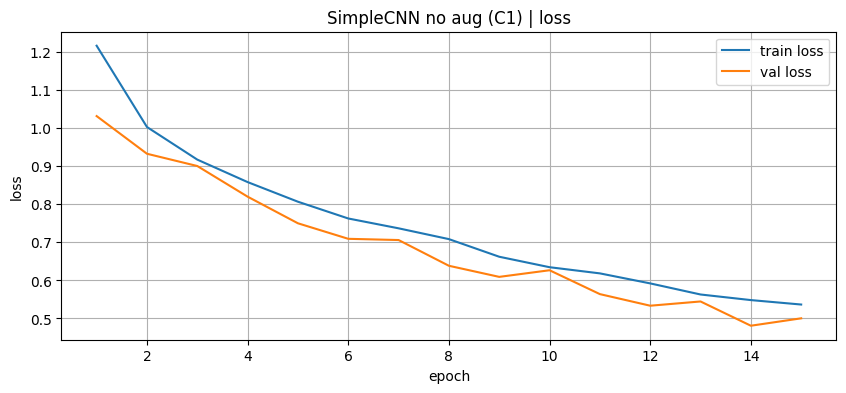

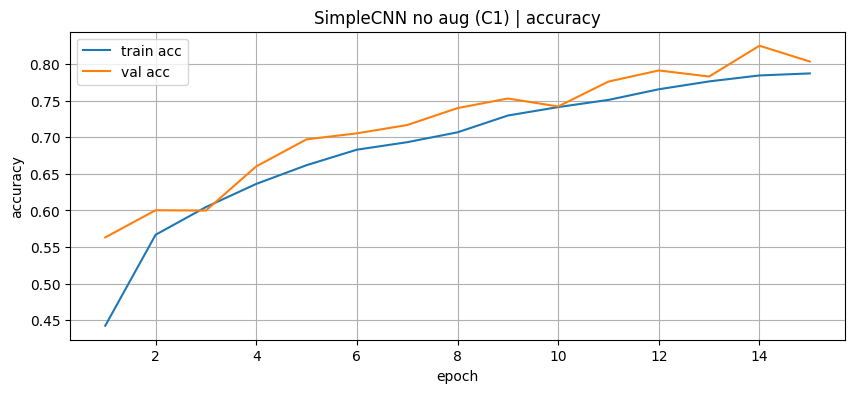

best_val_acc: 0.8248110271231659


In [ ]:
model_c1 = SimpleCNN(4).to(DEVICE)
optimizer_c1 = torch.optim.Adam(model_c1.parameters(), lr=1e-3, weight_decay=1e-4)
criterion_c1 = nn.CrossEntropyLoss()

hist_c1 = fit(model_c1, train_loader_c1, val_loader_c1, optimizer_c1, criterion_c1, epochs=15, verbose=True)
plot_history(hist_c1, title="SimpleCNN no aug (C1)")

best_val_acc_c1 = float(np.nanmax(hist_c1["val_acc"])) if len(hist_c1["val_acc"]) else float("nan")
print("best_val_acc:", best_val_acc_c1)

простая CNN c аугментаций

In [ ]:
train_loader_c2, val_loader_c2, test_loader_c2 = make_loaders_tl(
    ds_train_aug_baseline, ds_val_baseline, ds_test_baseline, batch_size=64
)

batch_c2 = next(iter(train_loader_c2))
x_c2, y_c2 = batch_c2
print("x:", x_c2.shape, x_c2.dtype)
print("y:", y_c2.shape, y_c2.dtype)

x: torch.Size([64, 3, 224, 224]) torch.float32
y: torch.Size([64]) torch.int64


Epoch 01/15 | train loss 1.3291, acc 0.367 | val loss 1.2651, acc 0.430 | 132.4s
Epoch 02/15 | train loss 1.1549, acc 0.492 | val loss 1.2098, acc 0.448 | 134.0s
Epoch 03/15 | train loss 1.0640, acc 0.533 | val loss 1.3093, acc 0.440 | 136.3s
Epoch 04/15 | train loss 0.9977, acc 0.562 | val loss 1.0778, acc 0.525 | 135.1s
Epoch 05/15 | train loss 0.9334, acc 0.591 | val loss 0.8851, acc 0.628 | 133.6s
Epoch 06/15 | train loss 0.8777, acc 0.622 | val loss 0.8323, acc 0.650 | 136.0s
Epoch 07/15 | train loss 0.8333, acc 0.643 | val loss 0.8525, acc 0.655 | 135.2s
Epoch 08/15 | train loss 0.7869, acc 0.670 | val loss 0.7129, acc 0.700 | 135.0s
Epoch 09/15 | train loss 0.7546, acc 0.684 | val loss 0.7771, acc 0.679 | 134.5s
Epoch 10/15 | train loss 0.7335, acc 0.697 | val loss 0.6997, acc 0.719 | 135.4s
Epoch 11/15 | train loss 0.7044, acc 0.710 | val loss 0.6074, acc 0.757 | 134.5s
Epoch 12/15 | train loss 0.6758, acc 0.727 | val loss 0.5907, acc 0.761 | 136.3s
Epoch 13/15 | train loss 0.6

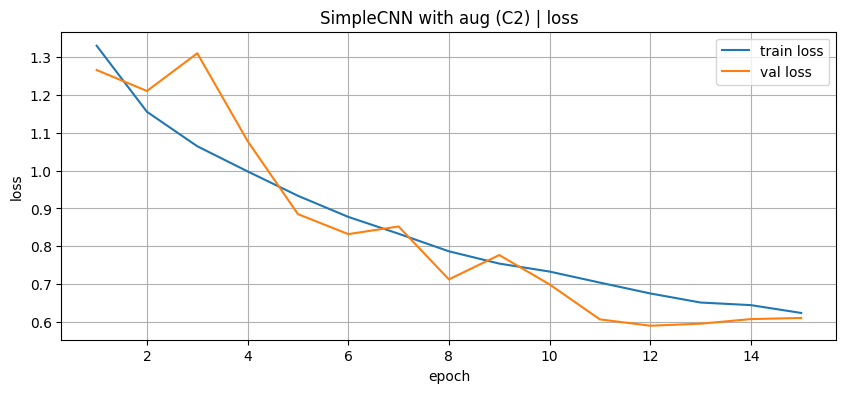

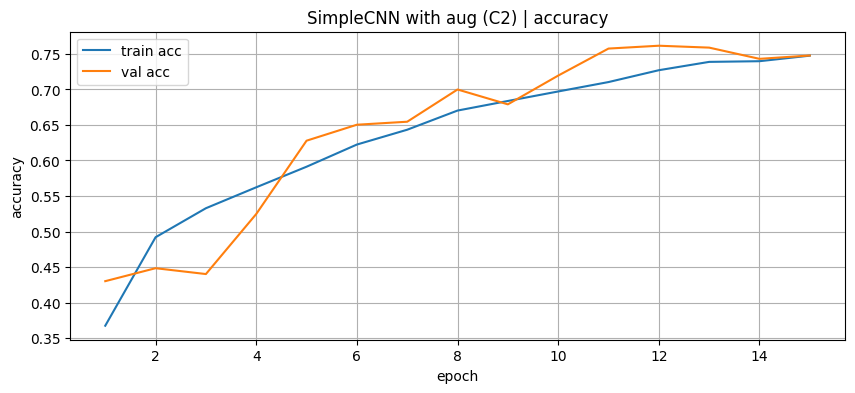

best_val_acc: 0.7614495331258337


In [ ]:
model_c2 = SimpleCNN(4).to(DEVICE)
optimizer_c2 = torch.optim.Adam(model_c2.parameters(), lr=1e-3, weight_decay=1e-4)
criterion_c2 = nn.CrossEntropyLoss()

hist_c2 = fit(model_c2, train_loader_c2, val_loader_c2, optimizer_c2, criterion_c2, epochs=15, verbose=True)
plot_history(hist_c2, title="SimpleCNN with aug (C2)")

best_val_acc_c2 = float(np.nanmax(hist_c2["val_acc"])) if len(hist_c2["val_acc"]) else float("nan")
print("best_val_acc:", best_val_acc_c2)

Эксперимент с аугментациями показал, что их применение не всегда приводит к улучшению качества. В нашем случае точность снизилась на 3.6–6.4%, что объясняется: (1) наличием предобработки в исходном датасете (CLAHE/SVD), (2) анатомическими ограничениями медицинских изображений, (3) недостаточной ёмкостью лёгкой модели. Этот результат подчёркивает важность тщательного подбора аугментаций с учётом доменной специфики, а не механического применения стандартных CV-трансформаций.


Фиксирую результат простой CNN модели без аугментаций :best_val_acc - 0.8248110271231659 как точку отсчета для оценки эффективности

Далее будем строить сложную модель - двухэтапное трансферное обучение на ResNet-50.

Для ResNet-50 была сохранена аугментация (RandomResizedCrop, RandomHorizontalFlip), так как предобученные на ImageNet веса обеспечивают устойчивость к сильным искажениям, а аугментации служат эффективным регуляризатором, предотвращая переобучение на ограниченном медицинском датасете. В отличие от простой CNN, большая модель способна извлекать пользу из augmented данных без потери точности

In [ ]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)
IMG_SIZE = 224

train_aug_ResNet50 = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
tf_test_ResNet50 = transforms.Compose([
    transforms.Resize(IMG_SIZE + 32),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

ds_train_aug_ResNet50 = datasets.ImageFolder(root="/content/папка_для разделения/train", transform=train_aug_ResNet50)
ds_train_eval = datasets.ImageFolder(root="/content/папка_для разделения/train", transform=tf_test_ResNet50)
ds_val_ResNet50 = datasets.ImageFolder(root="/content/папка_для разделения/val", transform=tf_test_ResNet50)
ds_test_ResNet50 = datasets.ImageFolder(root="/content/папка_для разделения/test", transform=tf_test_ResNet50)

In [ ]:
class_names = ds_train_aug_ResNet50.classes # тут неважно какой ds указывать
print("classes:", class_names)
print("Train full:", len(ds_train_aug_ResNet50))
print("Test:", len(ds_test_ResNet50))

classes: ['COVID', 'Lung opacity', 'Normal', 'Viral Pneumonia']
Train full: 20996
Test: 4504


In [ ]:
def get_resnet50_weights():
    # Пытаемся взять предобученные веса. Если не получилось – вернем None.
    try:
        w = ResNet50_Weights.DEFAULT
        # иногда ошибка возникает не здесь, а при фактической загрузке весов;
        # но на практике этого достаточно как "правильный путь".
        return w
    except Exception as e:
        print("Не удалось получить веса ResNet18_Weights.DEFAULT. Причина:", repr(e))
        return None

weights = get_resnet50_weights()
print("weights:", weights)
def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def build_resnet50(num_classes: int = 10, weights=weights) -> nn.Module:
    # Внимание: реальная загрузка весов может требовать интернет.
    # Если не получается – используйте weights=None.
    try:
        model = resnet50(weights=weights)
    except Exception as e:
        print("Не удалось загрузить предобученные веса. Переходим на weights=None. Причина:", repr(e))
        model = resnet50(weights=None)

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def set_requires_grad(module: nn.Module, flag: bool) -> None:
    for p in module.parameters():
        p.requires_grad = flag

weights: ResNet50_Weights.IMAGENET1K_V2


In [ ]:
def train_one_epoch_ResNet50(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate_ResNet50(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

def get_lr_ResNet50(optimizer) -> float:
    return float(optimizer.param_groups[0]["lr"])


def fit_ResNet50_with_save(model, train_loader, val_loader, optimizer, criterion, epochs=5, save_path="best_model.pth", verbose=True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}
    best_val_acc = 0.0
    best_model_state = None

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch_ResNet50(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate_ResNet50(model, val_loader, criterion)

        # Сохраняем лучшую модель
        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_model_state = copy.deepcopy(model.state_dict())
            torch.save(best_model_state, save_path)
            if verbose:
                print(f"⬆️ Лучшая модель сохранена (val_acc: {va_acc:.4f})")

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        history["lr"].append(get_lr_ResNet50(optimizer))

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"lr {get_lr_ResNet50(optimizer):.2e} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – останавливаем обучение.")
            break

    # Загружаем лучшую
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Загружена лучшая модель с val_acc: {best_val_acc:.4f}")

    return history

def plot_history_ResNet50(hist: Dict[str, List[float]], title: str = "", save_dir: str = None) -> None:
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)

    epochs = list(range(1, len(hist["train_loss"]) + 1))

    # 1. Loss
    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch"); plt.ylabel("loss"); plt.title(f"{title} | loss")
    plt.grid(True); plt.legend()
    if save_dir:
        plt.savefig(os.path.join(save_dir, "loss.png"), dpi=300, bbox_inches='tight')
    plt.show()

    # 2. Accuracy
    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.title(f"{title} | accuracy")
    plt.grid(True); plt.legend()
    if save_dir:
        plt.savefig(os.path.join(save_dir, "accuracy.png"), dpi=300, bbox_inches='tight')
    plt.show()

    # 3. LR
    plt.figure(figsize=(10, 3))
    plt.plot(epochs, hist["lr"], label="lr")
    plt.xlabel("epoch"); plt.ylabel("lr"); plt.title(f"{title} | lr")
    plt.grid(True); plt.legend()
    plt.show()

In [ ]:
model = build_resnet50(num_classes=4, weights=weights).to(DEVICE)
print(model)
print("Trainable params:", count_trainable_params(model))

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 199MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
train_loader, val_loader, test_loader = make_loaders_tl(
    ds_train_aug_ResNet50, ds_val_ResNet50, ds_test_ResNet50, batch_size=64
)

batch = next(iter(train_loader))
x, y = batch
print("x:", x.shape, x.dtype)
print("y:", y.shape, y.dtype)

x: torch.Size([64, 3, 224, 224]) torch.float32
y: torch.Size([64]) torch.int64


Trainable params (head-only): 8196

Phase 1: head-only training
⬆️ Лучшая модель сохранена (val_acc: 0.8266)
Epoch 01/15 | lr 1.00e-03 | train loss 0.6790, acc 0.750 | val loss 0.5027, acc 0.827 | 151.8s
Epoch 02/15 | lr 1.00e-03 | train loss 0.5055, acc 0.814 | val loss 0.4891, acc 0.819 | 150.5s
⬆️ Лучшая модель сохранена (val_acc: 0.8442)
Epoch 03/15 | lr 1.00e-03 | train loss 0.4632, acc 0.826 | val loss 0.4331, acc 0.844 | 148.3s
Epoch 04/15 | lr 1.00e-03 | train loss 0.4381, acc 0.836 | val loss 0.4274, acc 0.841 | 144.3s
⬆️ Лучшая модель сохранена (val_acc: 0.8524)
Epoch 05/15 | lr 1.00e-03 | train loss 0.4178, acc 0.843 | val loss 0.3989, acc 0.852 | 148.0s
⬆️ Лучшая модель сохранена (val_acc: 0.8544)
Epoch 06/15 | lr 1.00e-03 | train loss 0.4090, acc 0.847 | val loss 0.3917, acc 0.854 | 146.8s
⬆️ Лучшая модель сохранена (val_acc: 0.8619)
Epoch 07/15 | lr 1.00e-03 | train loss 0.4036, acc 0.849 | val loss 0.3796, acc 0.862 | 146.4s
Epoch 08/15 | lr 1.00e-03 | train loss 0.3881,

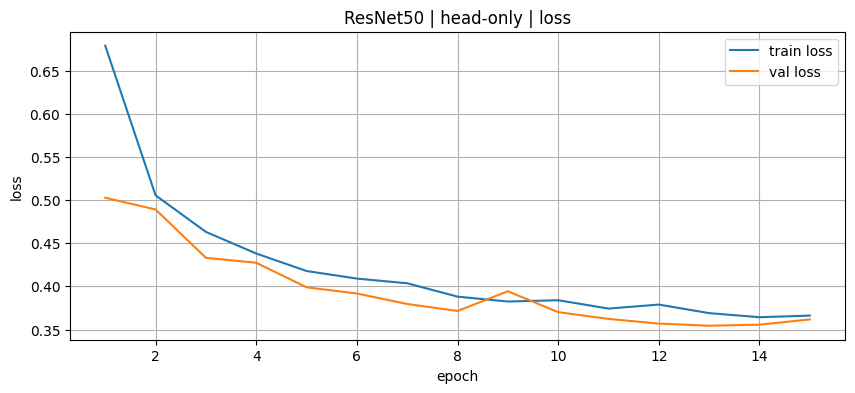

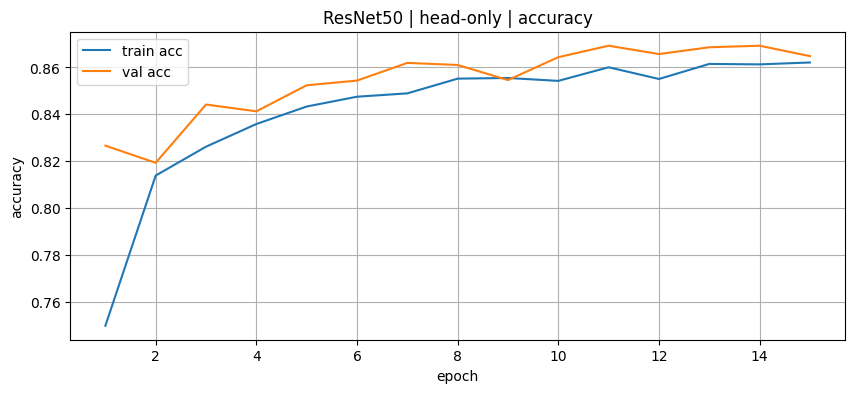

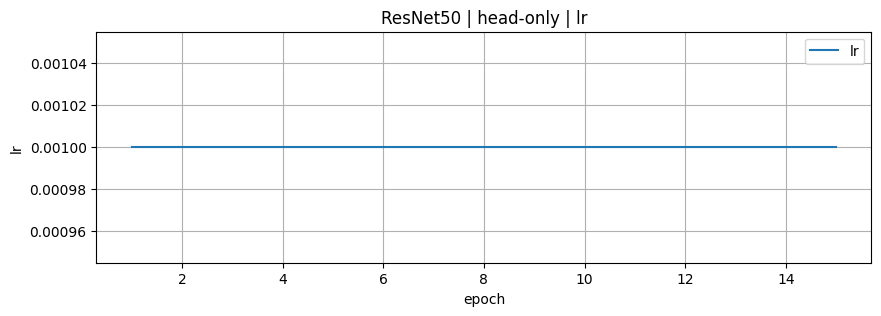

best_val_acc:  0.8692752334370831


In [ ]:
criterion = nn.CrossEntropyLoss()

model_head = build_resnet50(num_classes=4, weights=weights).to(DEVICE)

# freeze всё
set_requires_grad(model_head, False)
# размораживаем только голову
set_requires_grad(model_head.fc, True)

print("Trainable params (head-only):", count_trainable_params(model_head))

optimizer_head = torch.optim.Adam(model_head.fc.parameters(), lr=1e-3)

print("\n" + "=" * 80)
print("Phase 1: head-only training")
hist_head = fit_ResNet50_with_save(model_head, train_loader, val_loader, optimizer_head, criterion, epochs=15, save_path="../artifacts/weights/best_model_head.pth")
plot_history_ResNet50(hist_head, title="ResNet50 | head-only",save_dir="../artifacts/figures/CNN_head_only")
best_val_acc = float(np.nanmax(hist_head["val_acc"])) if len(hist_head["val_acc"]) else float("nan")
print("best_val_acc: ",best_val_acc)

Trainable params (layer4+fc): 14972932

Phase 2: fine-tuning layer4 + fc
⬆️ Лучшая модель сохранена (val_acc: 0.9108)
Epoch 01/10 | lr 1.00e-04 | train loss 0.2926, acc 0.891 | val loss 0.2337, acc 0.911 | 154.0s
⬆️ Лучшая модель сохранена (val_acc: 0.9302)
Epoch 02/10 | lr 1.00e-04 | train loss 0.1925, acc 0.929 | val loss 0.1972, acc 0.930 | 152.7s
⬆️ Лучшая модель сохранена (val_acc: 0.9315)
Epoch 03/10 | lr 1.00e-04 | train loss 0.1459, acc 0.947 | val loss 0.1824, acc 0.932 | 152.0s
⬆️ Лучшая модель сохранена (val_acc: 0.9464)
Epoch 04/10 | lr 1.00e-04 | train loss 0.1235, acc 0.955 | val loss 0.1551, acc 0.946 | 153.8s
⬆️ Лучшая модель сохранена (val_acc: 0.9553)
Epoch 05/10 | lr 1.00e-04 | train loss 0.1049, acc 0.962 | val loss 0.1331, acc 0.955 | 154.6s
Epoch 06/10 | lr 1.00e-04 | train loss 0.0847, acc 0.968 | val loss 0.1448, acc 0.951 | 153.1s
Epoch 07/10 | lr 1.00e-04 | train loss 0.0723, acc 0.973 | val loss 0.1224, acc 0.955 | 154.8s
⬆️ Лучшая модель сохранена (val_acc: 

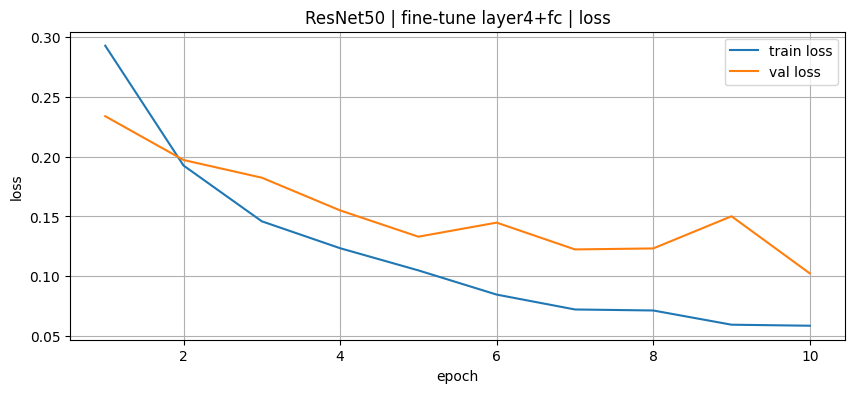

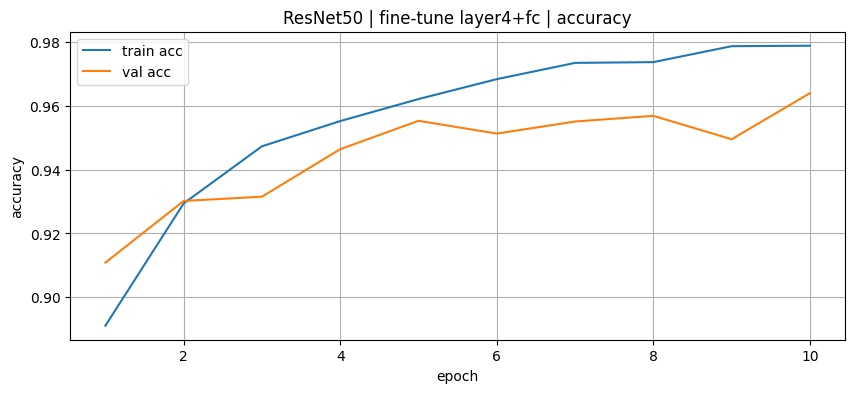

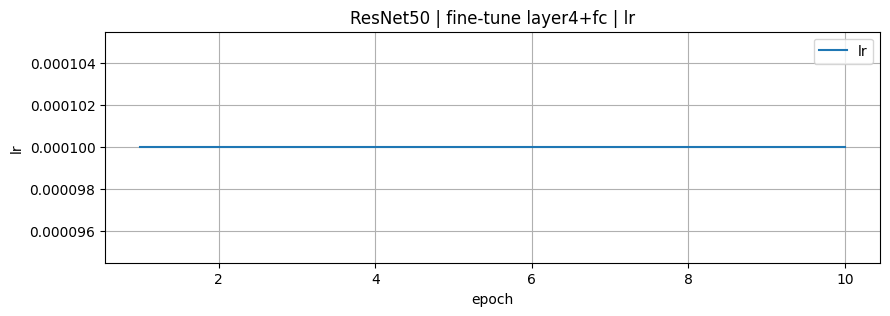

best_val_acc:  0.963983992885727


In [ ]:
# размораживаем layer4 и fc
set_requires_grad(model_head.layer4, True)
set_requires_grad(model_head.fc, True)

print("Trainable params (layer4+fc):", count_trainable_params(model_head))

# param groups: backbone меньше, head больше
params = [
    {"params": model_head.layer4.parameters(), "lr": 1e-4},
    {"params": model_head.fc.parameters(), "lr": 1e-3},
]

optimizer_ft = torch.optim.Adam(params, weight_decay=1e-4)

print("\n" + "=" * 80)
print("Phase 2: fine-tuning layer4 + fc")
hist_ft = fit_ResNet50_with_save(model_head, train_loader, val_loader, optimizer_ft, criterion, epochs=10,save_path="../artifacts/weights/best_model_full.pth")
plot_history_ResNet50(hist_ft, title="ResNet50 | fine-tune layer4+fc",save_dir="../artifacts/figures/CNN_full")
best_val_acc = float(np.nanmax(hist_ft["val_acc"])) if len(hist_ft["val_acc"]) else float("nan")
print("best_val_acc: ",best_val_acc)

Как и ожидалось трансферное обучение превоскодит простую CNN модель и дает прирост к точности на 14 %, достигая практически идеального результата

In [ ]:
@torch.no_grad()
def accuracy_on_loader(model, loader) -> float:
    model.eval()
    total_correct, total_seen = 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += y.size(0)
    return total_correct / total_seen

test_acc = accuracy_on_loader(model_head, test_loader)
print("Test acc:", round(test_acc, 4))

Test acc: 0.9678


In [1]:
# функция для сохранения файлов формата json
def save_json(obj: dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

In [ ]:
# конфиг лучшей модели
best_config = {
    "architecture": {
        "name": "ResNet50",
        "input_size": [3, 224, 224],
        "backbone": {
            "type": "resnet50",
            "frozen_layers": ["conv1", "layer1", "layer2", "layer3"],
            "trainable_layers": ["layer4"]
        },
        "classifier": {
            "type": "linear",
            "input_dim": 2048,
            "num_classes": 4,
            "trainable": True
        },
        "pretrained": True
    },
    "transforms": {
        "train": [
            "Resize(224)",
            "RandomRotation(10)",
            "RandomHorizontalFlip(p=0.5)",
            "ToTensor()",
            "Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])"
        ],
        "test": [
            "Resize(224)",
            "ToTensor()",
            "Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])"
        ]
    },
    "preprocess": {
        "resize": "Resize(224)",
        "to_tensor": "ToTensor()",
        "normalize": {
            "mean": [0.485, 0.456, 0.406],
            "std": [0.229, 0.224, 0.225]
        }
    },
    "augmentation": {
        "random_rotation": {
            "degrees": 10
        },
        "random_horizontal_flip": {
            "probability": 0.5
        }
    },
    "hyperparameters": {
        "learning_rate": {
            "head_only_phase": {
                "fc": 0.001
            },
            "fine_tune_phase": {
                "layer4": 0.0001,
                "fc": 0.001
            }
        },
        "optimizer": "Adam",
        "loss_function": "CrossEntropyLoss",
        "weight_decay": 0.0001,
        "batch_size": 64
    },
    "seed": 42,
    "dataset": "Chest X-Ray (COVID, Normal, Lung Opacity, Viral Pneumonia)"
}

save_json(best_config, Path("../configs/training_best_model_config.json"))

In [6]:
# Конфигурация параметров инференса
inference_config = {
    "model": {
        "architecture": {
            "name": "ResNet50",
            "input_size": [3, 224, 224],
            "backbone": {
                "type": "resnet50",
            },
            "classifier": {
                "type": "linear",
                "input_dim": 2048,
                "num_classes": 4
            },
            "weights_path": "artifacts/best_model_full.pth"
        },
        "classes": ["COVID", "Normal", "Lung Opacity", "Viral Pneumonia"]
    },
    "preprocess": {
        "resize": [224, 224],
        "normalize": {
            "mean": [0.485, 0.456, 0.406],
            "std": [0.229, 0.224, 0.225]
        },
        "to_tensor": True
    },
}
save_json(inference_config, Path("../configs/inference_best_model_config.json"))

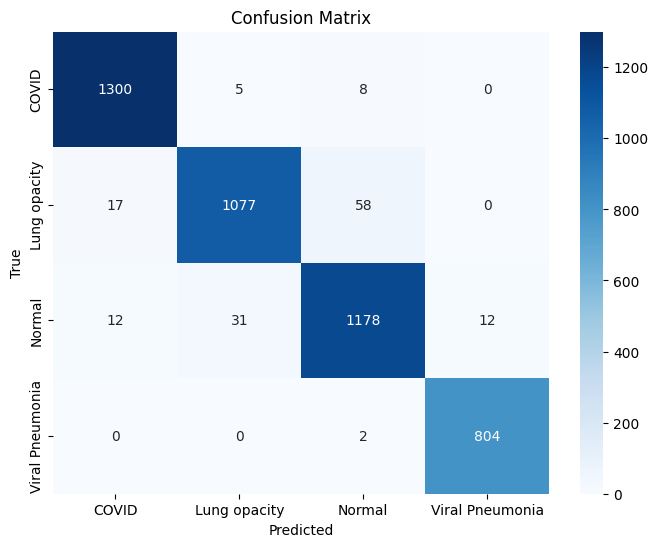

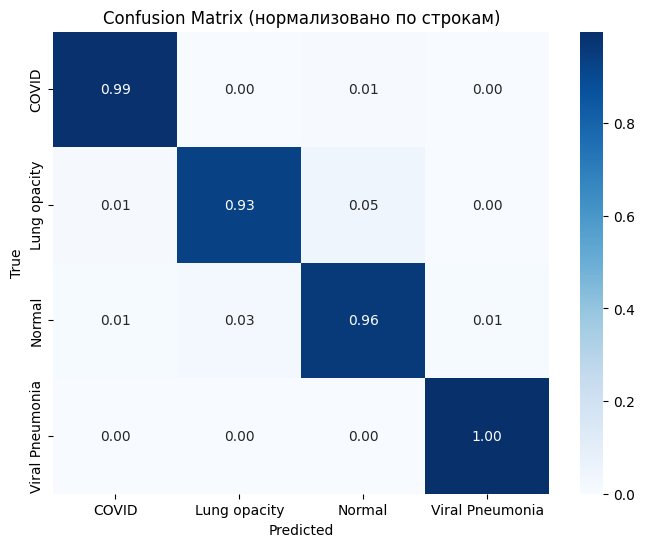


Classification Report:
                 precision    recall  f1-score   support

          COVID     0.9782    0.9901    0.9841      1313
   Lung opacity     0.9677    0.9349    0.9510      1152
         Normal     0.9454    0.9554    0.9504      1233
Viral Pneumonia     0.9853    0.9975    0.9914       806

       accuracy                         0.9678      4504
      macro avg     0.9691    0.9695    0.9692      4504
   weighted avg     0.9678    0.9678    0.9677      4504


Топ ошибок классификации (true_label -> predicted_label):
  Lung opacity -> Normal: 58
  Normal -> Lung opacity: 31
  Lung opacity -> COVID: 17
  Normal -> COVID: 12
  Normal -> Viral Pneumonia: 12
  COVID -> Normal: 8
  COVID -> Lung opacity: 5
  Viral Pneumonia -> Normal: 2


In [ ]:
@torch.no_grad()
def get_all_preds(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)

# Получаем предсказания
y_true, y_pred = get_all_preds(model_head, test_loader)
class_names = ds_test_ResNet50.classes

# 1. Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig("../artifacts/figures/CNN_confucion_matrix.png", dpi=100,bbox_inches='tight')
plt.show()

# 2. Нормализованная confusion matrix (доли по строкам)
cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (нормализовано по строкам)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# 3. Per-class метрики
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# 4. Топ ошибок
errors = []
for i in range(len(y_true)):
    if y_true[i] != y_pred[i]:
        errors.append((y_true[i], y_pred[i]))

from collections import Counter
error_counts = Counter(errors)
print("\nТоп ошибок классификации (true_label -> predicted_label):")
for (true_label, pred_label), count in error_counts.most_common(10):
    print(f"  {class_names[true_label]} -> {class_names[pred_label]}: {count}")

Для проверки гипотезы о превосходстве трансформерных архитектур над классическими CNN в задачу введу Swin Transformer (Tiny) с аналогичной стратегией two-stage transfer learning

In [ ]:
BASE_PATH = '/content/папка_для разделения'
IMG_SIZE = 224


train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(os.path.join(BASE_PATH, 'train'), transform=train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(BASE_PATH, 'val'), transform=val_test_transform)
test_dataset  = datasets.ImageFolder(os.path.join(BASE_PATH, 'test'), transform=val_test_transform)

In [ ]:
train_loader, val_loader, test_loader = make_loaders_tl(
    train_dataset, val_dataset, test_dataset, batch_size=64
)
batch = next(iter(train_loader))
x, y = batch
print("x:", x.shape, x.dtype)
print("y:", y.shape, y.dtype)

x: torch.Size([64, 3, 224, 224]) torch.float32
y: torch.Size([64]) torch.int64


Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 185MB/s] 


Trainable params (head-only): 3076

Phase 1: head-only training (Swin-T)
⬆️ Лучшая модель сохранена (val_acc: 0.8413)
Epoch 01/15 | lr 1.00e-03 | train loss 0.6078, acc 0.770 | val loss 0.4503, acc 0.841 | 132.8s
⬆️ Лучшая модель сохранена (val_acc: 0.8584)
Epoch 02/15 | lr 1.00e-03 | train loss 0.4556, acc 0.828 | val loss 0.3872, acc 0.858 | 142.8s
⬆️ Лучшая модель сохранена (val_acc: 0.8653)
Epoch 03/15 | lr 1.00e-03 | train loss 0.4222, acc 0.842 | val loss 0.3659, acc 0.865 | 143.9s
Epoch 04/15 | lr 1.00e-03 | train loss 0.4043, acc 0.845 | val loss 0.3598, acc 0.864 | 143.3s
⬆️ Лучшая модель сохранена (val_acc: 0.8717)
Epoch 05/15 | lr 1.00e-03 | train loss 0.3908, acc 0.850 | val loss 0.3450, acc 0.872 | 143.4s
⬆️ Лучшая модель сохранена (val_acc: 0.8775)
Epoch 06/15 | lr 1.00e-03 | train loss 0.3837, acc 0.853 | val loss 0.3414, acc 0.878 | 143.5s
⬆️ Лучшая модель сохранена (val_acc: 0.8777)
Epoch 07/15 | lr 1.00e-03 | train loss 0.3818, acc 0.853 | val loss 0.3403, acc 0.878 |

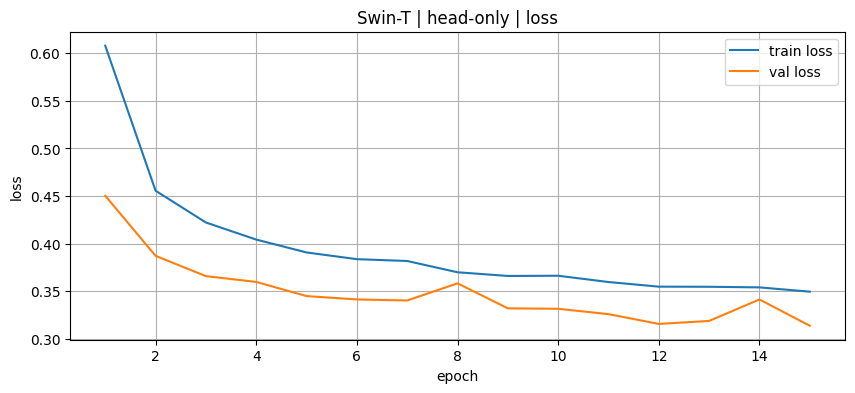

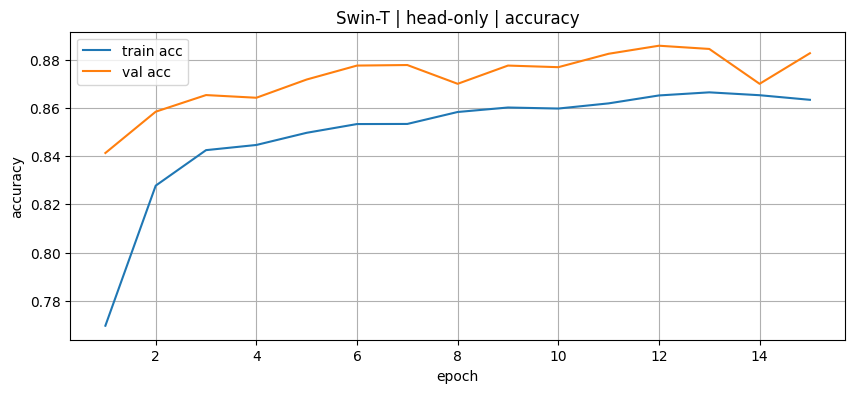

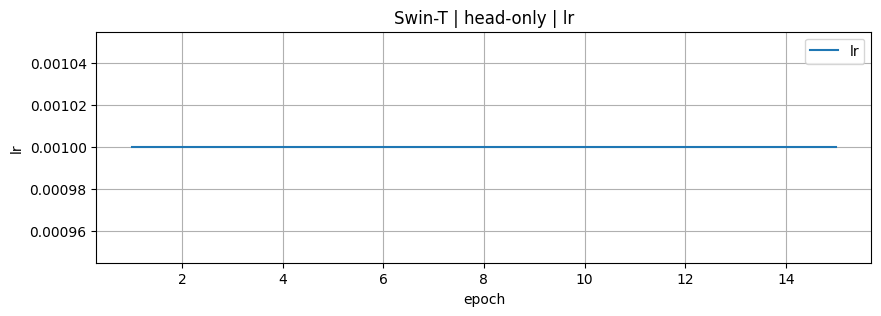

best_val_acc: 0.8857269897732325


In [ ]:
criterion = nn.CrossEntropyLoss()
weights = Swin_T_Weights.IMAGENET1K_V1

model_head =swin_t(weights=weights).to(DEVICE)


set_requires_grad(model_head, False)
model_head.head = nn.Linear(768, 4)
set_requires_grad(model_head.head, True)
model_head = model_head.to(DEVICE)
print("Trainable params (head-only):", count_trainable_params(model_head))

optimizer_head = torch.optim.Adam(model_head.head.parameters(), lr=1e-3)

print("\n" + "="*80)
print("Phase 1: head-only training (Swin-T)")
hist_head = fit_ResNet50_with_save(
    model_head, train_loader, val_loader, optimizer_head, criterion,
    epochs=15, save_path="../artifacts/weights/swin_best_head.pth"
)
plot_history_ResNet50(hist_head, title="Swin-T | head-only")
best_val_acc = float(np.nanmax(hist_head["val_acc"])) if len(hist_head["val_acc"]) else float("nan")
print("best_val_acc:", best_val_acc)

Trainable params (fine-tune): 27218344
⬆️ Лучшая модель сохранена (val_acc: 0.8866)
Epoch 01/10 | lr 1.00e-04 | train loss 0.3103, acc 0.883 | val loss 0.3098, acc 0.887 | 275.0s
⬆️ Лучшая модель сохранена (val_acc: 0.9264)
Epoch 02/10 | lr 1.00e-04 | train loss 0.2393, acc 0.911 | val loss 0.2014, acc 0.926 | 284.4s
⬆️ Лучшая модель сохранена (val_acc: 0.9362)
Epoch 03/10 | lr 1.00e-04 | train loss 0.2075, acc 0.924 | val loss 0.1816, acc 0.936 | 284.0s
⬆️ Лучшая модель сохранена (val_acc: 0.9444)
Epoch 04/10 | lr 1.00e-04 | train loss 0.1903, acc 0.931 | val loss 0.1506, acc 0.944 | 282.7s
Epoch 05/10 | lr 1.00e-04 | train loss 0.1757, acc 0.933 | val loss 0.1770, acc 0.941 | 283.7s
Epoch 06/10 | lr 1.00e-04 | train loss 0.1655, acc 0.940 | val loss 0.1555, acc 0.944 | 282.8s
⬆️ Лучшая модель сохранена (val_acc: 0.9506)
Epoch 07/10 | lr 1.00e-04 | train loss 0.1590, acc 0.943 | val loss 0.1328, acc 0.951 | 283.5s
⬆️ Лучшая модель сохранена (val_acc: 0.9513)
Epoch 08/10 | lr 1.00e-04 

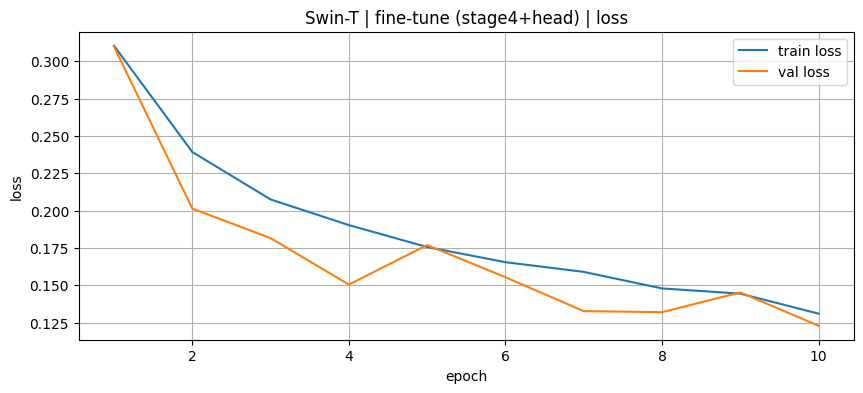

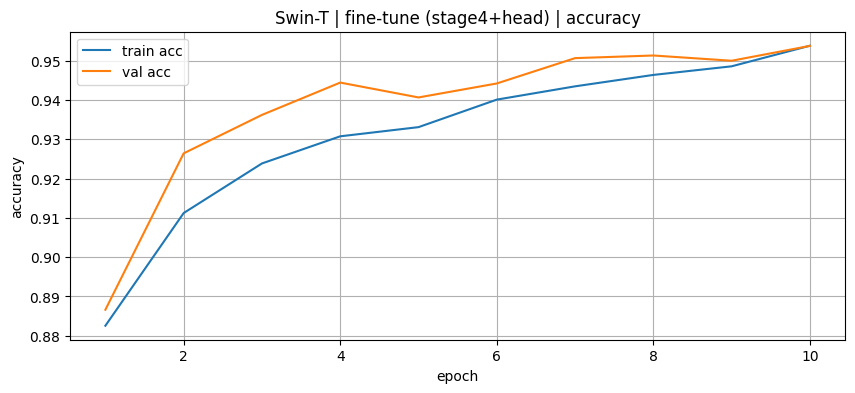

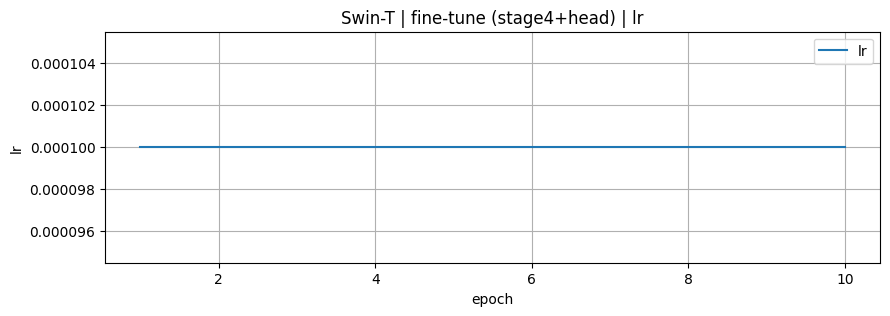

best_val_acc: 0.953757225433526


In [ ]:
model_head.load_state_dict(torch.load("../artifacts/weights/swin_best_head.pth"))

# Разморозить всё, затем заморозить стадии 0,1,2,3 (оставить stage 4 и head)
set_requires_grad(model_head, True)
set_requires_grad(model_head.features[0], False)
set_requires_grad(model_head.features[1], False)
set_requires_grad(model_head.features[2], False)
set_requires_grad(model_head.features[3], False)


# Для честного сравнения с ResNet (обучали layer4+fc) разморозим последнюю стадию:
set_requires_grad(model_head.features[3], True)

print("Trainable params (fine-tune):", count_trainable_params(model_head))

# Группы: stage 4 → lr 1e-4, head → lr 1e-3
params = [
    {"params": model_head.features[3].parameters(), "lr": 1e-4},
    {"params": model_head.head.parameters(), "lr": 1e-3},
]
optimizer_ft = torch.optim.Adam(params, weight_decay=1e-4)

hist_ft = fit_ResNet50_with_save(
    model_head, train_loader, val_loader, optimizer_ft, criterion,
    epochs=10, save_path="../artifacts/weights/swin_best_full.pth"
)
plot_history_ResNet50(hist_ft, title="Swin-T | fine-tune (stage4+head)")
best_val_acc = float(np.nanmax(hist_ft["val_acc"])) if len(hist_ft["val_acc"]) else float("nan")
print("best_val_acc:", best_val_acc)

По результатам проведённого эксперимента с архитектурой Swin Transformer (Tiny), обученной по идентичной двухэтапной стратегии трансферного обучения, исходная гипотеза о безусловном превосходстве трансформерных моделей над классическими CNN в рамках данной задачи не подтвердилась. Сравнительный анализ показал, что ResNet-50 достиг более высокой точности на валидации (96.40% против 95.38% у Swin-T) при существенно меньшем времени обучения и сопоставимом количестве обучаемых параметров. Полученные данные свидетельствуют о том, что при ограниченном объёме данных и выраженной локальной структуре медицинских изображений индуктивное смещение свёрточных сетей обеспечивает более эффективное извлечение признаков и стабильную обобщающую способность. На основании этих результатов в качестве финальной архитектуры для развёртывания выбрана ResNet-50, обеспечивающая оптимальный баланс между точностью, скоростью инференса и вычислительной эффективностью

In [2]:
data = [
    {
        "task": "classification",
        "dataset": "X-Ray Chest",
        "seed": 42,
        "model_summary": "SimpleCNN (no aug)",
        "optimizer": "Adam",
        "lr": 1e-3,
        "epochs_trained": 15,
        "best_val_accuracy": 0.8248,
        "test_accuracy": None,
        "notes": "Baseline without augmentation"
    },
    {
        "task": "classification",
        "dataset": "X-Ray Chest",
        "seed": 42,
        "model_summary": "SimpleCNN (with aug)",
        "optimizer": "Adam",
        "lr": 1e-3,
        "epochs_trained": 15,
        "best_val_accuracy": 0.7614,
        "test_accuracy": None,
        "notes": "Baseline with augmentation"
    },
    {
        "task": "classification",
        "dataset": "X-Ray Chest",
        "seed": 42,
        "model_summary": "ResNet-50 pretrained, fine-tuned layer4+fc",
        "optimizer": "Adam",
        "lr": 1e-4,
        "epochs_trained": 10,
        "best_val_accuracy": 0.9640,
        "test_accuracy": 0.9678,
        "notes": "Selected for deployment"
    },
    {
        "task": "classification",
        "dataset": "X-Ray Chest",
        "seed": 42,
        "model_summary": "Swin-T pretrained, fine-tuned stage4+head",
        "optimizer": "Adam",
        "lr": 1e-4,
        "epochs_trained": 10,
        "best_val_accuracy": 0.9538,
        "test_accuracy": None,
        "notes": "Transformer, slower training (~80 min)"
    }
]

df = pd.DataFrame(data)
df.to_csv("../artifacts/model_comparison.csv", index=False, encoding="utf-8-sig")

df

,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,notes
0,classification,X-Ray Chest,42,SimpleCNN (no aug),Adam,0.0010,15,0.8248,NaN,Baseline without augmentation
1,classification,X-Ray Chest,42,SimpleCNN (with aug),Adam,0.0010,15,0.7614,NaN,Baseline with augmentation
2,classification,X-Ray Chest,42,"ResNet-50 pretrained, fine-tuned layer4+fc",Adam,0.0001,10,0.9640,0.9678,Selected for deployment
3,classification,X-Ray Chest,42,"Swin-T pretrained, fine-tuned stage4+head",Adam,0.0001,10,0.9538,NaN,"Transformer, slower training (~80 min)"
